In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/competitions/mlp-jan-2026-kaggle-assignment-2/sample_submission.csv
/kaggle/input/competitions/mlp-jan-2026-kaggle-assignment-2/train.csv
/kaggle/input/competitions/mlp-jan-2026-kaggle-assignment-2/test.csv


In [2]:
sample=pd.read_csv("/kaggle/input/competitions/mlp-jan-2026-kaggle-assignment-2/sample_submission.csv")
train=pd.read_csv("/kaggle/input/competitions/mlp-jan-2026-kaggle-assignment-2/train.csv")
test=pd.read_csv("/kaggle/input/competitions/mlp-jan-2026-kaggle-assignment-2/test.csv")

In [3]:
import matplotlib
from sklearn.linear_model import SGDClassifier,RidgeClassifier,Perceptron,LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import BaggingClassifier,RandomForestClassifier,AdaBoostClassifier,GradientBoostingClassifier
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score
from sklearn.model_selection import GridSearchCV,train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler,OneHotEncoder,OrdinalEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline


In [4]:
train.head()

,ID,mushroom_id,cap-shape,cap-surface,cap-color,bruises,number_of_bruises,odor,gill-attachment,gill-spacing,...,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat,class
0,1,0,convex,smooth,brown,bruises,7,pungent,gills free from stalk,close,...,white,white,partial,white,1.0,pendant,black,scattered,urban,p
1,2,1,convex,smooth,yellow,bruises,20,almond,gills free from stalk,close,...,white,white,partial,white,1.0,pendant,brown,numerous,grasses,e
2,3,3,convex,scaly,white,bruises,11,pungent,gills free from stalk,close,...,white,white,partial,white,1.0,pendant,black,scattered,urban,p
3,4,4,convex,smooth,gray,no,0,NaN,gills free from stalk,crowded,...,white,white,partial,white,1.0,evanescent,brown,abundant,grasses,e
4,5,5,convex,scaly,yellow,bruises,8,almond,gills free from stalk,close,...,white,white,partial,white,1.0,pendant,black,numerous,grasses,e


# DATATYPES of Columnns

In [5]:
train.dtypes

ID                            int64
mushroom_id                   int64
cap-shape                    object
cap-surface                  object
cap-color                    object
bruises                      object
number_of_bruises             int64
odor                         object
gill-attachment              object
gill-spacing                 object
gill-size                    object
gill-color                   object
stalk-shape                  object
stalk-root                   object
stalk-surface-above-ring     object
stalk-surface-below-ring     object
stalk-color-above-ring       object
stalk-color-below-ring       object
veil-type                    object
veil-color                   object
ring-number                 float64
ring-type                    object
spore-print-color            object
population                   object
habitat                      object
class                        object
dtype: object

In [6]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7000 entries, 0 to 6999
Data columns (total 26 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   ID                        7000 non-null   int64  
 1   mushroom_id               7000 non-null   int64  
 2   cap-shape                 7000 non-null   object 
 3   cap-surface               7000 non-null   object 
 4   cap-color                 7000 non-null   object 
 5   bruises                   7000 non-null   object 
 6   number_of_bruises         7000 non-null   int64  
 7   odor                      3764 non-null   object 
 8   gill-attachment           7000 non-null   object 
 9   gill-spacing              7000 non-null   object 
 10  gill-size                 7000 non-null   object 
 11  gill-color                7000 non-null   object 
 12  stalk-shape               7000 non-null   object 
 13  stalk-root                6808 non-null   object 
 14  stalk-su

# Descriptive Statistics of Columns

In [7]:
train.select_dtypes(include=["number"]).mean()





ID                   3500.500000
mushroom_id          3850.617714
number_of_bruises       5.459571
ring-number             1.080988
dtype: float64

In [8]:
train.select_dtypes(include=["number"]).median()

ID                   3500.5
mushroom_id          3755.5
number_of_bruises       0.0
ring-number             1.0
dtype: float64

In [9]:
num_mode=train.select_dtypes(include=["number"]).mode().iloc[0]
num_mode


ID                   1.0
mushroom_id          0.0
number_of_bruises    0.0
ring-number          1.0
Name: 0, dtype: float64

In [10]:
cat_mode=train.select_dtypes(include=["object"]).mode().iloc[0]
cat_mode

cap-shape                                     convex
cap-surface                                    scaly
cap-color                                       gray
bruises                                           no
odor                                            foul
gill-attachment                gills free from stalk
gill-spacing                                   close
gill-size                                      broad
gill-color                                      pink
stalk-shape                 stalk tapers toward base
stalk-root                                   bulbous
stalk-surface-above-ring                      smooth
stalk-surface-below-ring                      smooth
stalk-color-above-ring                         white
stalk-color-below-ring                         white
veil-type                                    partial
veil-color                                     white
ring-type                                    pendant
spore-print-color                             

In [11]:
train.describe().T

,count,mean,std,min,25%,50%,75%,max
ID,7000.0,3500.500000,2020.870275,1.0,1750.75,3500.5,5250.25,7000.0
mushroom_id,7000.0,3850.617714,2208.389867,0.0,2000.75,3755.5,5602.25,8118.0
number_of_bruises,7000.0,5.459571,7.723528,0.0,0.00,0.0,11.00,24.0
ring-number,6964.0,1.080988,0.272836,1.0,1.00,1.0,1.00,2.0


In [12]:
train_cat=train.select_dtypes(include=["object"])



In [13]:
train_cat.describe().T

,count,unique,top,freq
cap-shape,7000,5,convex,3272
cap-surface,7000,3,scaly,2774
cap-color,7000,10,gray,1840
bruises,7000,2,no,3924
odor,3764,8,foul,1968
gill-attachment,7000,2,gills free from stalk,6982
gill-spacing,7000,2,close,5752
gill-size,7000,2,broad,5128
gill-color,7000,11,pink,1492
stalk-shape,7000,2,stalk tapers toward base,4032


# Missing Values

In [14]:
train.isnull().sum()

ID                             0
mushroom_id                    0
cap-shape                      0
cap-surface                    0
cap-color                      0
bruises                        0
number_of_bruises              0
odor                        3236
gill-attachment                0
gill-spacing                   0
gill-size                      0
gill-color                     0
stalk-shape                    0
stalk-root                   192
stalk-surface-above-ring       0
stalk-surface-below-ring       0
stalk-color-above-ring         0
stalk-color-below-ring         0
veil-type                      0
veil-color                     0
ring-number                   36
ring-type                     36
spore-print-color              0
population                     0
habitat                        0
class                          0
dtype: int64

In [15]:
train["odor"].mode()[0]

'foul'

In [16]:
train["odor"] = train["odor"].fillna(train["odor"].mode().iloc[0])
train["stalk-root"] = train["stalk-root"].fillna(train["stalk-root"].mode().iloc[0])
train["ring-number"] = train["ring-number"].fillna(train["ring-number"].mean())
train["ring-type"] = train["ring-type"].fillna(train["ring-type"].mode().iloc[0])


In [17]:
test["odor"] = test["odor"].fillna(test["odor"].mode().iloc[0])
test["stalk-root"] = test["stalk-root"].fillna(test["stalk-root"].mode().iloc[0])
test["ring-number"] = test["ring-number"].fillna(test["ring-number"].mean())
test["ring-type"] = test["ring-type"].fillna(test["ring-type"].mode().iloc[0])

In [18]:
train.isna().sum()

ID                          0
mushroom_id                 0
cap-shape                   0
cap-surface                 0
cap-color                   0
bruises                     0
number_of_bruises           0
odor                        0
gill-attachment             0
gill-spacing                0
gill-size                   0
gill-color                  0
stalk-shape                 0
stalk-root                  0
stalk-surface-above-ring    0
stalk-surface-below-ring    0
stalk-color-above-ring      0
stalk-color-below-ring      0
veil-type                   0
veil-color                  0
ring-number                 0
ring-type                   0
spore-print-color           0
population                  0
habitat                     0
class                       0
dtype: int64

# Duplicate values

In [19]:
train.duplicated().sum()

np.int64(0)

Since there are no duplicates, no rows were removed.

# Outliers

In [20]:
num_cols=train.select_dtypes(include=["number"])
num_cols

,ID,mushroom_id,number_of_bruises,ring-number
0,1,0,7,1.000000
1,2,1,20,1.000000
2,3,3,11,1.000000
3,4,4,0,1.000000
4,5,5,8,1.000000
...,...,...,...,...
6995,6996,8111,0,2.000000
6996,6997,8113,0,1.000000
6997,6998,8114,0,1.080988
6998,6999,8117,0,1.000000


In [21]:

for col in num_cols:
    Q1=train[col].quantile(0.25)
    Q3=train[col].quantile(0.75)
    IQR=Q3-Q1
    lower=Q1-(1.5*IQR)
    upper=Q3+(1.5*IQR)

    outliers=train[(train[col]<lower) | (train[col]>upper)]
print(f"{col}: {len(outliers)}")

ring-number: 600


In ring-number these are not outliers just different category.

# Visualization

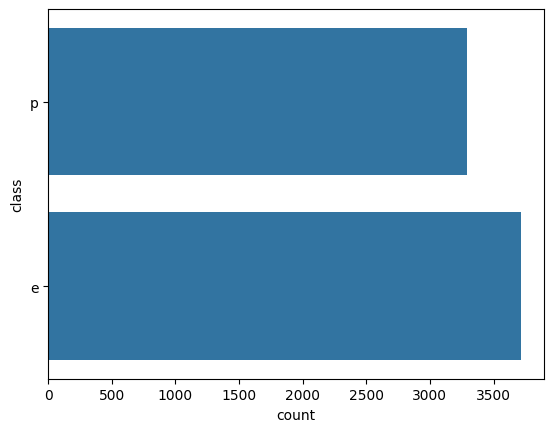

In [22]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.countplot(train["class"])
plt.show()

The dataset is fairly balanced, with a slightly higher number of edible (e) mushrooms compared to poisonous (p) ones

<Axes: xlabel='class', ylabel='number_of_bruises'>

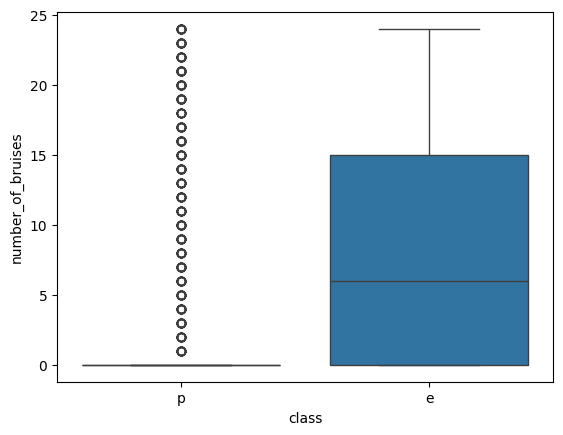

In [23]:
sns.boxplot(x=train["class"], y=train["number_of_bruises"])


Poisonous mushrooms mostly have zero bruises, while edible mushrooms show a wider distribution with higher values.

<Axes: xlabel='odor', ylabel='count'>

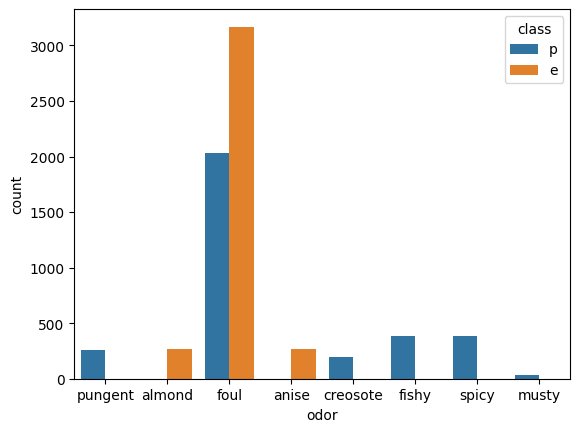

In [24]:
sns.countplot(x="odor", hue="class", data=train)

Odor is a strong discriminator: pungent, creosote, fishy, spicy, and musty odors almost always indicate poisonous mushrooms, while almond and anise odors reliably signal edible ones.

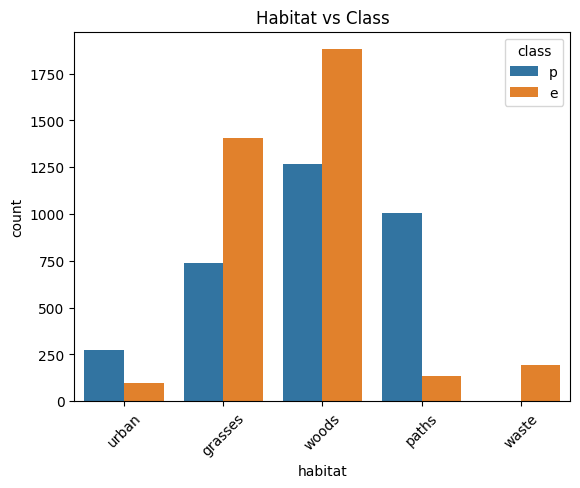

In [25]:
sns.countplot(x="habitat", hue="class", data=train)
plt.xticks(rotation=45)
plt.title("Habitat vs Class")
plt.show()

Habitat provides context: poisonous mushrooms dominate in urban and path environments, while edible mushrooms are more common in grasses and waste areas; woods support both.

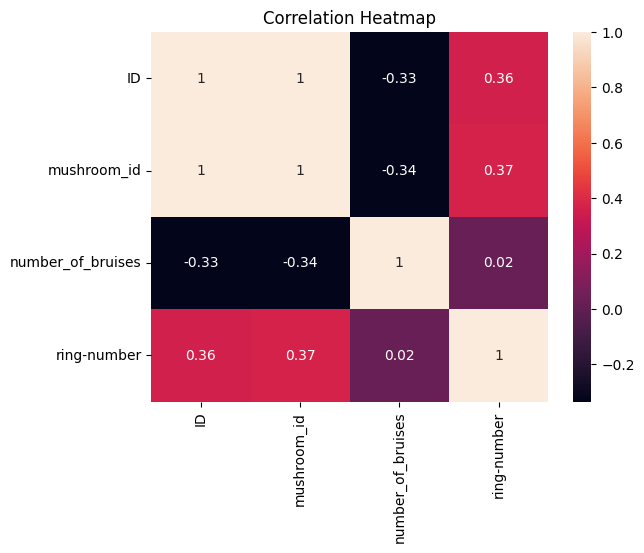

In [26]:
sns.heatmap(train.select_dtypes(include=["number"]).corr(), annot=True)
plt.title("Correlation Heatmap")
plt.show()

# Scaling and Encoding

In [27]:
X = train.drop("class", axis=1)
y = train["class"].map({"e": 0, "p": 1})

X = pd.get_dummies(X)

In [28]:
X_test = test.copy()

X_test = pd.get_dummies(X_test)
X, X_test = X.align(X_test, join="left", axis=1, fill_value=0)

In [29]:
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


In [30]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)   
X_val_scaled = scaler.transform(X_val)         

# Models

In [31]:
models = {
    "Logistic": LogisticRegression(max_iter=1000),
    "KNN": KNeighborsClassifier(),
    "DecisionTree": DecisionTreeClassifier(),
    "RandomForest": RandomForestClassifier(),
    "GradientBoost": GradientBoostingClassifier(),
    "SGD": SGDClassifier(),
    "Perceptron": Perceptron()
}

from sklearn.metrics import accuracy_score

results = {}

for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_val_scaled)
    results[name] = accuracy_score(y_val, y_pred)

print(results)

{'Logistic': 1.0, 'KNN': 1.0, 'DecisionTree': 1.0, 'RandomForest': 1.0, 'GradientBoost': 1.0, 'SGD': 1.0, 'Perceptron': 1.0}


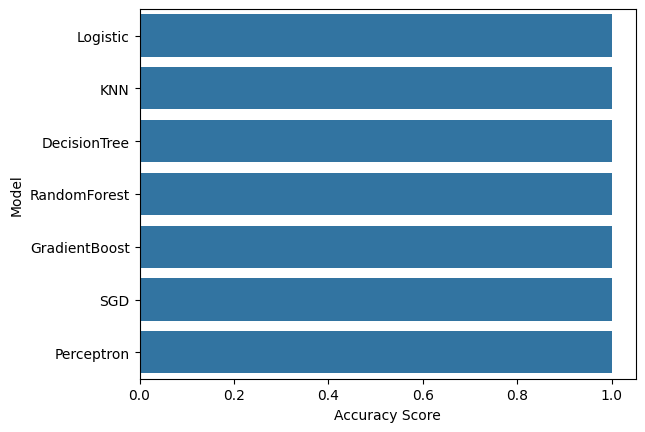

In [32]:
results_df = pd.DataFrame(results.items(), columns=["Model","Accuracy Score"])

results_df=results_df.sort_values(by="Accuracy Score", ascending=True)
sns.barplot(x="Accuracy Score", y="Model", data=results_df)
plt.show()

# Hyperparameter Tuning 

In [33]:

params_lr = {
    "C": [0.01, 0.1, 1, 10],
    "penalty": ["l2"],
    "solver": ["lbfgs"]
}

grid_lr = GridSearchCV(LogisticRegression(max_iter=1000), params_lr, cv=3)
grid_lr.fit(X_train_scaled, y_train)

print("Best LR score:", grid_lr.best_score_)

print("Best LR Params:", grid_lr.best_params_)
print("Best LR Params:", grid_lr.best_estimator_)

Best LR score: 1.0
Best LR Params: {'C': 0.01, 'penalty': 'l2', 'solver': 'lbfgs'}
Best LR Params: LogisticRegression(C=0.01, max_iter=1000)


In [34]:
from sklearn.tree import DecisionTreeClassifier

params_dt = {
    "max_depth": [3, 5, 10, None],
    "min_samples_split": [2, 5, 10]
}

grid_dt = GridSearchCV(DecisionTreeClassifier(), params_dt, cv=3)
grid_dt.fit(X_train, y_train)
print("Best DT score:", grid_dt.best_score_)
print("Best DT Params:", grid_dt.best_params_)
print("Best DT estimator:", grid_dt.best_estimator_)

Best DT score: 0.9998213647731333
Best DT Params: {'max_depth': 10, 'min_samples_split': 2}
Best DT estimator: DecisionTreeClassifier(max_depth=10)


In [35]:
from sklearn.ensemble import RandomForestClassifier

params_rf = {
    "n_estimators": [50, 100],
    "max_depth": [5, 10, None],
    "min_samples_split": [2, 5]
}

grid_rf = GridSearchCV(RandomForestClassifier(), params_rf, cv=3)
grid_rf.fit(X_train, y_train)

print("Best RF score:", grid_rf.best_score_)
print("Best RF Params:", grid_rf.best_params_)
print("Best RF estimator:", grid_rf.best_estimator_)

Best RF score: 1.0
Best RF Params: {'max_depth': 10, 'min_samples_split': 2, 'n_estimators': 50}
Best RF estimator: RandomForestClassifier(max_depth=10, n_estimators=50)


In [36]:
from sklearn.ensemble import GradientBoostingClassifier

params_gb = {
    "n_estimators": [50, 100],
    "learning_rate": [0.01, 0.1],
    "max_depth": [3, 5]
}

grid_gb = GridSearchCV(GradientBoostingClassifier(), params_gb, cv=3)
grid_gb.fit(X_train, y_train)
print("Best gb score:", grid_gb.best_score_)
print("Best gb Params:", grid_gb.best_params_)
print("Best gb estimator:", grid_gb.best_estimator_)


Best gb score: 1.0
Best gb Params: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 50}
Best gb estimator: GradientBoostingClassifier(n_estimators=50)


In [37]:
best_models = {
"DecisionTree": grid_dt.best_score_,
"Logistics Regression": grid_lr.best_score_,

"RandomForest": grid_rf.best_score_,
}


print(best_models)


{'DecisionTree': np.float64(0.9998213647731333), 'Logistics Regression': np.float64(1.0), 'RandomForest': np.float64(1.0)}


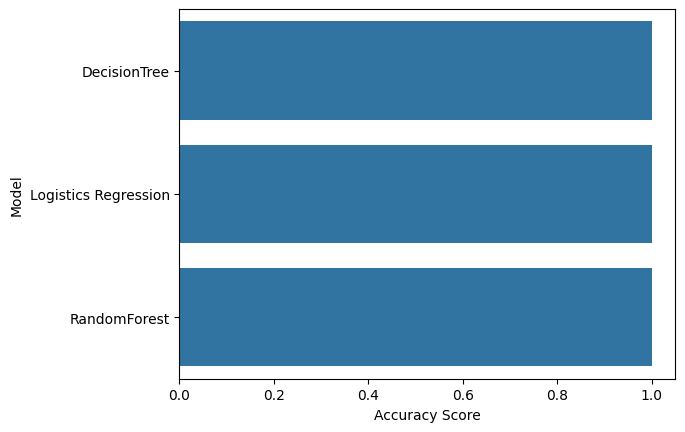

In [38]:
best_models_df=pd.DataFrame(list(best_models.items()),
                            columns=["Model","Accuracy Score"])
sns.barplot(x="Accuracy Score", y="Model", data=best_models_df)
plt.show()


In [39]:
best=grid_gb.best_estimator_


In [40]:
test_preds=best.predict(X_test)

In [41]:
print(test_preds)

[0 0 0 ... 0 1 0]


In [42]:
# Convert predictions (if needed)
test_preds = pd.Series(test_preds).map({0: "e", 1: "p"})

# Create submission
submission = pd.DataFrame({
    "ID": range(1, len(test_preds) + 1),
    "class": test_preds
})

submission.to_csv("submission.csv", index=False)

In [43]:
submission.head()

,ID,class
0,1,e
1,2,e
2,3,e
3,4,e
4,5,e
